# 공유폴더에 접근하기






In [ ]:
# 구글 드라이브 마운트

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip" -d "/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/"

unzip:  cannot find or open /content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip, /content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip.zip or /content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset.zip.ZIP.


In [ ]:
root_dir = '/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/초급 강의 노트/생물정보학/10. 의료이미지 기반 환자진단 및 바이오마커 탐색/Covid_Dataset'




# 데이터 준비 및 전처리

**COVID-CT-Dataset: A CT Image Dataset about COVID-19**

[Original data source](https://github.com/UCSD-AI4H/COVID-CT)

[Related paper](https://arxiv.org/pdf/2003.13865.pdf)

### 이미지 예시 출력

In [ ]:
import random
import os
import cv2
import matplotlib.pyplot as plt

### 데이터 분포 확인

In [ ]:
import os

In [ ]:
def print_files_in_dir(root_dir, prefix):
    files = os.listdir(root_dir)
    lab = ['COVID', "Non-COVID"]
    for i, file in enumerate(files):
        path = os.path.join(root_dir, file)
        file_list = os.listdir(path)
        print(f"{prefix} 데이터의 {lab[i]} 수: {len(file_list)}")

        # print(f"해당 폴더의 데이터의 수 {len(file_list)}")

In [ ]:
phase = "Train"
# root_dir 문자열 바로 뒤에 슬래시(/)를 추가하여 경로를 완성합니다.
print_files_in_dir(root_dir + f"/Covid_{phase}", phase)
print()

phase = "Valid"
print_files_in_dir(root_dir + f"/Covid_{phase}", phase)
print()

phase = "Test"
print_files_in_dir(root_dir + f"/Covid_{phase}", phase)

Train 데이터의 COVID 수: 191
Train 데이터의 Non-COVID 수: 234

Valid 데이터의 COVID 수: 60
Valid 데이터의 Non-COVID 수: 58

Test 데이터의 COVID 수: 98
Test 데이터의 Non-COVID 수: 105


### 데이터 전처리

In [ ]:
# 필요한 모듈 불러오기

import numpy as np
import torch
from torchvision import datasets, transforms
import torch.utils.data as data

In [ ]:
# 디바이스 설정 (GPU 사용 가능하면 GPU 사용하도록)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

random_seed = 2022

torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

np.random.seed(random_seed)
random.seed(random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# 데이터 transform 적용하기

normalize = transforms.Normalize(mean=[0,0,0], std=[1,1,1])
image_transforms = {
    'train': transforms.Compose([
    transforms.Resize(256),

    # data augmentation
    transforms.RandomResizedCrop((224),scale=(0.5,1.0)),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),
    normalize
    ]),

    'valid': transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
    ])
}

In [ ]:
train_dataset_folder = root_dir + 'Covid_Train'
val_dataset_folder = root_dir + 'Covid_Valid'
test_dataset_folder = root_dir + 'Covid_Test'

In [ ]:
# 슬래시(/)를 명시적으로 추가하거나 os.path.join을 사용하여 경로를 올바르게 이어줍니다.
train_dataset_folder = root_dir + '/Covid_Train'
val_dataset_folder = root_dir + '/Covid_Valid'
test_dataset_folder = root_dir + '/Covid_Test'

# 위 코드를 다시 실행하신 후 아래 데이터셋 객체를 다시 생성해 보세요.
train_dataset = datasets.ImageFolder(root=train_dataset_folder, transform=image_transforms['train'])
valid_dataset = datasets.ImageFolder(root=val_dataset_folder, transform=image_transforms['valid'])
test_dataset = datasets.ImageFolder(root=test_dataset_folder, transform=image_transforms['valid'])

In [ ]:
# DataLoader을 위한 hyperparameter 설정

train_params = {
    'batch_size': 64,
    'shuffle': True,
    'num_workers': 1,
    'drop_last': False}

valid_params = {
    'batch_size': 64,
    'shuffle': False,
    'num_workers': 1,
    'drop_last': False}

In [ ]:
train_loader = data.DataLoader(train_dataset, **train_params)
valid_loader = data.DataLoader(valid_dataset, **valid_params)
test_loader = data.DataLoader(test_dataset, **valid_params)

In [ ]:
# Train DataLoader 데이터 확인해보기

for x, y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [ ]:
# Valid DataLoader 데이터 확인해보기

for x, y in valid_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


# 모델 만들기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. 잔차 블록(Residual Block) 정의
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # 첫 번째 합성곱 층
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels) # 권장 순서: Conv -> BN -> ReLU

        # 두 번째 합성곱 층
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 스킵 커넥션(Skip Connection) 차원 맞추기
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)      # 원본 데이터를 저장해둠

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += identity                  # 층을 건너뛰어 원본 데이터와 더함 (Skip Connection)
        out = F.relu(out)

        return out


# 2. 전체 모델 조립 (Global Average Pooling 적용)
class DeeperResCNN(nn.Module):
    def __init__(self, num_classes=2, dropout_p=0.3):
        super(DeeperResCNN, self).__init__()

        # 초기 입력 특징 추출
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 224x224 -> 112x112
        )

        # 잔차 블록을 이용해 층을 깊게 쌓음
        self.layer1 = ResidualBlock(32, 64, stride=2)  # 112x112 -> 56x56
        self.layer2 = ResidualBlock(64, 128, stride=2) # 56x56 -> 28x28

        # 🌟 [핵심 개선 포인트] 차원 압축 및 과적합 방지
        # 28x28 공간을 1x1로 평균 내어 128개의 채널 특징만 깔끔하게 남깁니다.
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 과적합 방지 및 분류기
        self.dropout = nn.Dropout(p=dropout_p)
        # 이제 100,352가 아닌 128개의 핵심 특징만 전달됩니다!
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.init_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x = self.avgpool(x)          # (Batch, 128, 28, 28) -> (Batch, 128, 1, 1)
        x = x.flatten(start_dim=1)   # (Batch, 128)
        x = self.dropout(x)
        x = self.classifier(x)

        return x

# 모델 확인
model = DeeperResCNN()
print(model)

DeeperResCNN(
  (init_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 

 이 아키텍처에 적용된 핵심 원리들.


*   Functional 방식의 활용: 층을 건너뛰는 스킵 커넥션(Skip Connection) 구조를 짜기 위해, 직진만 하는 nn.Sequential 대신 nn.Module을 상속받아 데이터의 흐름을 자유롭게 설계하는 방식을 채택했습니다. 실무에서는 이 방식을 훨씬 더 많이 사용합니다.
*   잔차 연결 (Skip Connection): 네트워크가 깊어질수록 학습이 어려워지는 것을 막기 위해, forward 함수 내에서 identity = self.shortcut(x)로 원본 데이터를 저장한 후, 층의 연산 결과에 out += identity 형태로 더해주었습니다.  
*   깊어진 계층과 특징 추출: 얕은 층에서는 선이나 점 같은 기본적인 패턴을 감지하고, 층이 깊어짐에 따라 바퀴나 창문처럼 더 복잡한 형태의 객체를 인식할 수 있도록 모델의 용량(Capacity)을 확장했습니다.  
*   정규화 위치 최적화: Conv -> BatchNorm -> ReLU 순서로 배치했습니다. 비대칭 분포(음수 제거 후)를 정규화하게 되어 효과가 감소하는 역효과를 막고 학습을 안정화하기 위함입니다.
*   Dropout (과적합 억제): 학습 과정에서 은닉층의 노드들을 무작위 비율(0.3)로 꺼버린 상태로 학습하여, 모델이 훈련 데이터에만 완벽하게 맞춰지는 과적합(Overfitting)을 억제하도록 설계했습니다.

In [ ]:
model = DeeperResCNN(num_classes=2)
model

DeeperResCNN(
  (init_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 

##구조 상세
이 모델은 크게 두 개의 합성곱 블록(Block 1 & 2)과 하나의 분류기(Classifier)로 구성되어 있습니다.

1. 합성곱 블록 (Block 1 & Block 2)이미지에서 특징(선, 색상, 질감 등)을 추출하는 역할을 합니다.
*   Conv2d (합성곱 층): 이미지 위를 슬라이딩하며 필터(커널)를 적용해 특징 맵(Feature Map)을 생성합니다. Block 1에서는 3개의 색상 채널(RGB)을 받아 32개의 특징 맵을 만들고, Block 2에서는 32개를 받아 64개로 더 복잡한 특징을 추출합니다.
*   BatchNorm2d (배치 정규화): 각 층의 활성화 값을 정규화합니다. 이는 학습을 더 빠르고 안정적으로 만들어 줍니다.  ReLU (활성화 함수): 네트워크에 비선형성을 부여합니다. 음수 값을 0으로 만들어 모델이 복잡한 패턴을 학습할 수 있게 돕습니다.
*   MaxPool2d (최대 풀링): 특징 맵의 크기를 줄입니다 (2x2 영역에서 가장 큰 값만 남김). 이 과정은 연산량을 줄이고, 약간의 위치 변화에도 덜 민감하게(이동 불변성) 만들어 줍니다.

<br>

2. 분류기 (Classifier)추출된 특징들을 바탕으로 이미지가 10개의 클래스(비행기, 자동차, 새 등) 중 어디에 속하는지 판별합니다.
*   Flatten: 2차원 특징 맵들을 1차원 벡터로 길게 폅니다.
*   Dropout (드롭아웃): 학습 과정에서 무작위로 신경망의 일부 연결을 끊습니다 (여기서는 30%). 이는 모델이 특정 특징에만 과도하게 의존하는 것(과적합)을 방지합니다.  
*   Linear (완전 연결 층): 길게 펴진 특징들을 종합하여 최종적으로 10개의 클래스에 대한 예측 값(로짓)을 출력합니다.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.5 MB/s eta 0:00:00


In [ ]:
import optuna
import copy
import torch
import torch.nn as nn
from time import time
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 진행 상황을 깔끔하게 보기 위해 불필요한 로그 출력 줄이기
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Optuna가 최적의 하이퍼파라미터를 찾기 위해 반복해서 실행할 함수입니다.
    """
    # 1. 하이퍼파라미터 탐색 공간 설정 (Optuna가 알아서 값을 뽑아냅니다)[cite: 3]
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)                 # 학습률
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True) # L2 규제
    dropout_p = trial.suggest_float("dropout_p", 0.1, 0.5)               # 드롭아웃 비율

    # 2. 모델 및 옵티마이저 생성 (탐색된 파라미터 적용)
    model = DeeperResCNN(num_classes=2, dropout_p=dropout_p).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    # Early Stopping 설정
    best_val_loss = float('inf')
    patience = 5
    no_improve = 0

    # 3. 모델 학습 루프 시작
    for epo in range(10):  # train_epoch 변수 사용 (예: 20~50)
        model.train()

        for v_i, label in train_loader:
            v_i = v_i.float().to(device)
            output = model(v_i)
            loss = loss_fn(output, label.to(device))

            opt.zero_grad()
            loss.backward()
            opt.step()

        # 4. 검증 (Validation)
        epoch_val_loss = 0.0
        val_batches = 0
        model.eval()

        with torch.set_grad_enabled(False):
            for v_i, label in valid_loader:
                v_i = v_i.float().to(device)
                output = model(v_i)
                loss = loss_fn(output, label.to(device))
                epoch_val_loss += loss.item()
                val_batches += 1

        avg_val_loss = epoch_val_loss / val_batches

        # 🌟 5. Optuna Pruning (가망이 없는 Trial은 도중에 잘라냄)[cite: 3]
        trial.report(avg_val_loss, step=epo)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # 6. 일반 Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            # 설정한 인내심을 넘기면 현재 Trial 종료
            break

    # 7. 목적 함수 반환: 검증 손실(Val Loss)을 최소화하도록 반환[cite: 3]
    return best_val_loss


# =====================================================================
# 🚀 Study 생성 및 최적화 실행
# =====================================================================
print('--- Optuna 하이퍼파라미터 최적화 시작 ---')

# Study 생성: Val Loss를 '최소화'하는 방향으로 진행하며, 성능이 중간값 이하인 경우 조기 중단(MedianPruner)[cite: 3]
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

# 총 30번(n_trials)의 다양한 조합을 시도합니다. 컴퓨터 성능에 따라 조절하세요.
study.optimize(objective, n_trials=30, show_progress_bar=True)

# 최적화 완료 후 결과 출력
print("\n🏆 최적화 완료!")
print(f"가장 낮았던 검증 손실 (Best Val Loss): {study.best_value:.4f}")
print("발견된 최적의 하이퍼파라미터 (Best Params):")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

# 파라미터 중요도 확인[cite: 3]
importances = optuna.importance.get_param_importances(study)
print("\n📊 파라미터 중요도:")
for key, value in importances.items():
    print(f"  - {key}: {value:.4f}")

--- Optuna 하이퍼파라미터 최적화 시작 ---


  0%|          | 0/30 [00:00<?, ?it/s]


🏆 최적화 완료!
가장 낮았던 검증 손실 (Best Val Loss): 0.5520
발견된 최적의 하이퍼파라미터 (Best Params):
  - lr: 0.003909597637147028
  - weight_decay: 0.00012126988654545972
  - dropout_p: 0.38125355652816445

📊 파라미터 중요도:
  - lr: 0.5146
  - dropout_p: 0.3493
  - weight_decay: 0.1361


# 모델 학습 (Model training)

### 모델 학습을 위한 설정

In [ ]:
"""# 모델 학습 (Model training)

### 모델 학습을 위한 설정
"""
# Optuna가 찾아낸 최적의 하이퍼파라미터를 변수에 담습니다.
best_lr = study.best_params['lr']
best_wd = study.best_params['weight_decay']
best_dropout = study.best_params['dropout_p']

print(f"✅ Optuna 최적값 적용 -> Learning Rate: {best_lr:.5f}, Weight Decay: {best_wd:.5f}, Dropout: {best_dropout:.2f}")

# 최종 학습에 사용할 에포크 설정 (Optuna 탐색 때보다 길게 설정하여 끝까지 학습시킵니다)
train_epoch = 30

# 최적의 드롭아웃 비율을 적용하여 최종 모델을 새롭게(초기화) 생성합니다!
model = DeeperResCNN(num_classes=2, dropout_p=best_dropout)

# 최적의 학습률과 가중치 감쇠(L2 규제)를 적용하여 옵티마이저를 셋팅합니다.
opt = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = torch.nn.CrossEntropyLoss()

import copy
from prettytable import PrettyTable
from time import time
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

✅ Optuna 최적값 적용 -> Learning Rate: 0.00391, Weight Decay: 0.00012, Dropout: 0.38


### 모델 학습 진횅

In [ ]:
# ==========================================================
# 🌟 1. Optuna 최적값 적용 및 셋팅 (이 부분을 꼭 넣어주세요!)
# ==========================================================
best_lr = study.best_params['lr']
best_wd = study.best_params['weight_decay']
best_dropout = study.best_params['dropout_p']

print(f"✅ Optuna 최적값 적용 -> Learning Rate: {best_lr:.5f}, Weight Decay: {best_wd:.5f}, Dropout: {best_dropout:.2f}")

# 실전 학습은 넉넉하게 30 에포크로 설정합니다. (Early Stopping이 알아서 멈춰줍니다)
train_epoch = 30

# 최적의 드롭아웃을 적용하여 최종 모델을 만들고 GPU에 올립니다.
model = DeeperResCNN(num_classes=2, dropout_p=best_dropout).to(device)

# 최적의 학습률과 가중치 감쇠를 적용하여 옵티마이저를 만듭니다.
opt = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = torch.nn.CrossEntropyLoss()


# ==========================================================
# 🌟 2. 최종 학습 루프 진행
# ==========================================================
loss_history_train = []
loss_history_val = []

# Early Stopping 및 Best Loss 초기화
best_val_loss = float('inf') # 최저 검증 오차를 무한대로 설정
patience = 5                 # 5 에포크 동안 개선이 없으면 조기 종료
no_improve = 0               # 개선되지 않은 에포크 횟수 카운트

# Best 모델 초기화
import copy
model_best = copy.deepcopy(model)

# 결과 정리를 위한 PrettyTable
valid_metric_record = []
valid_metric_header = ["# epoch", "Val Loss", "Accuracy", "sensitivity", "specificity", "roc_score"]
from prettytable import PrettyTable
table = PrettyTable(valid_metric_header)

float2str = lambda x:'%0.4f'%x # float 소숫점 4자리까지만 str로 바꾸기

# 학습 진행
from time import time
print('\n--- Go for Final Training ---')
t_start = time()

# 🌟 여기는 10이 아니라 넉넉하게 설정한 train_epoch(30)이 들어갑니다.
for epo in range(train_epoch):
    # Model training
    model.train()

    # Mini-batch 학습
    for i, (v_i, label) in enumerate(train_loader):
        v_i = v_i.float().to(device)
        output = model(v_i)

        loss = loss_fn(output, label.to(device))
        loss_history_train.append(loss.item())

        opt.zero_grad()
        loss.backward()
        opt.step()

    # gradient tracking X
    with torch.set_grad_enabled(False):
        y_pred = []
        y_score = []
        y_label = []

        epoch_val_loss = 0.0
        val_batches = 0

        model.eval()

        for i, (v_i, label) in enumerate(valid_loader):
            v_i = v_i.float().to(device)
            output = model(v_i)
            loss = loss_fn(output, label.to(device))

            loss_history_val.append(loss.item())
            epoch_val_loss += loss.item()
            val_batches += 1

            pred = output.argmax(dim=1, keepdim=True)
            score = torch.nn.Softmax(dim = 1)(output)[:,1]

            pred = pred.cpu().numpy()
            score = score.cpu().numpy()
            label = label.cpu().numpy()

            y_label = y_label + label.flatten().tolist()
            y_pred = y_pred + pred.flatten().tolist()
            y_score = y_score + score.flatten().tolist()

    # 에포크당 평균 검증 손실 계산
    avg_val_loss = epoch_val_loss / val_batches

    # metric 계산
    from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
    classification_metrics = classification_report(y_label, y_pred,
                        target_names = ['CT_NonCOVID', 'CT_COVID'],
                        output_dict= True, zero_division=0)

    sensitivity = classification_metrics['CT_COVID']['recall']
    specificity = classification_metrics['CT_NonCOVID']['recall']
    accuracy = classification_metrics['accuracy']
    conf_matrix = confusion_matrix(y_label, y_pred)
    roc_score = roc_auc_score(y_label, y_score)

    lst = ["epoch " + str(epo+1)] + list(map(float2str,[avg_val_loss, accuracy, sensitivity, specificity, roc_score]))
    table.add_row(lst)
    valid_metric_record.append(lst)

    # Val Loss 기준으로 Best Model 업데이트 및 Early Stopping 체크
    if avg_val_loss < best_val_loss:
        model_best = copy.deepcopy(model)
        best_val_loss = avg_val_loss
        no_improve = 0
    else:
        no_improve += 1

    print('Validation at Epoch '+ str(epo + 1) + ' , Val Loss: ' + str(avg_val_loss)[:7] + ' , Accuracy: ' + str(accuracy)[:7] + ' , sensitivity: '\
                         + str(sensitivity)[:7] + ', specificity: ' + str(f"{specificity:.4f}") +' , roc_score: '+str(roc_score)[:7])

    if no_improve >= patience:
        print(f"\n🚨 Early Stopping 발동! {patience} 에포크 동안 검증 손실(Val Loss)이 개선되지 않아 학습을 조기 종료합니다. (Best Val Loss: {best_val_loss:.4f})")
        break

✅ Optuna 최적값 적용 -> Learning Rate: 0.00391, Weight Decay: 0.00012, Dropout: 0.38

--- Go for Final Training ---
Validation at Epoch 1 , Val Loss: 0.81055 , Accuracy: 0.50847 , sensitivity: 0.96666, specificity: 0.0345 , roc_score: 0.23074
Validation at Epoch 2 , Val Loss: 0.77755 , Accuracy: 0.50847 , sensitivity: 0.91666, specificity: 0.0862 , roc_score: 0.71695
Validation at Epoch 3 , Val Loss: 0.62750 , Accuracy: 0.66101 , sensitivity: 0.91666, specificity: 0.3966 , roc_score: 0.77011
Validation at Epoch 4 , Val Loss: 0.68015 , Accuracy: 0.62711 , sensitivity: 0.3, specificity: 0.9655 , roc_score: 0.78362
Validation at Epoch 5 , Val Loss: 0.83805 , Accuracy: 0.49152 , sensitivity: 0.0, specificity: 1.0000 , roc_score: 0.79022
Validation at Epoch 6 , Val Loss: 0.63469 , Accuracy: 0.65254 , sensitivity: 1.0, specificity: 0.2931 , roc_score: 0.81436
Validation at Epoch 7 , Val Loss: 0.61831 , Accuracy: 0.68644 , sensitivity: 0.41666, specificity: 0.9655 , roc_score: 0.82327
Validation a

# 모델 테스트 (model testing)

In [ ]:
# Test dataloader 확인
for i, (v_i, label) in enumerate(test_loader):
    print(v_i.shape)
    print(label.shape)
    break

torch.Size([64, 3, 224, 224])
torch.Size([64])


### 모델 테스트 진행

In [ ]:
# 테스트 진행

model = model_best

y_pred = []
y_label = []
y_score = []

model.eval()
for i, (v_i, label) in enumerate(test_loader):
    # input data gpu에 올리기
    v_i = v_i.float().to(device)

    with torch.set_grad_enabled(False):
        # forward-pass
        output = model(v_i)

        # 미리 정의한 손실함수(MSE)로 손실(loss) 계산
        loss = loss_fn(output, label.to(device))

        # 각 iteration 마다 loss 기록
        loss_history_val.append(loss.item())

        pred = output.argmax(dim=1, keepdim=True)
        score = nn.Softmax(dim = 1)(output)[:,1]

        # 예측값, 참값 cpu로 옮기고 numpy 형으로 변환
        pred = pred.cpu().numpy()
        score = score.cpu().numpy()
        label = label.cpu().numpy()

    # 예측값, 참값 기록하기
    y_label = y_label + label.flatten().tolist()
    y_pred = y_pred + pred.flatten().tolist()
    y_score = y_score + score.flatten().tolist()

# metric 계산
classification_metrics = classification_report(y_label, y_pred,
                    target_names = ['CT_NonCOVID', 'CT_COVID'],
                    output_dict= True)
# sensitivity is the recall of the positive class
sensitivity = classification_metrics['CT_COVID']['recall']
# specificity is the recall of the negative class
specificity = classification_metrics['CT_NonCOVID']['recall']
# accuracy
accuracy = classification_metrics['accuracy']
# confusion matrix
conf_matrix = confusion_matrix(y_label, y_pred)
# roc score
roc_score = roc_auc_score(y_label, y_score)

# 각 epoch 마다 결과 출력
print('Validation at Epoch '+ str(epo + 1) + ' , Accuracy: ' + str(accuracy)[:7] + ' , sensitivity: '\
                        + str(sensitivity)[:7] + ' specificity: ' + str(f"{specificity}") +' , roc_score: '+str(roc_score)[:7])


Validation at Epoch 14 , Accuracy: 0.71428 , sensitivity: 0.56122 specificity: 0.8571428571428571 , roc_score: 0.77667


### 테스트 결과 시각화

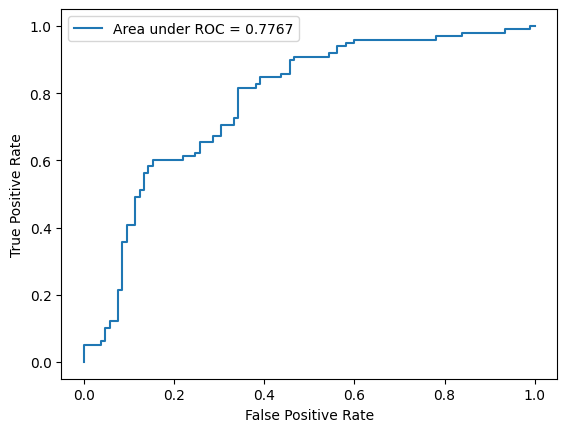

In [ ]:
# plot the roc curve
fpr, tpr, _ = roc_curve(y_label, y_score)
plt.plot(fpr, tpr, label = "Area under ROC = {:.4f}".format(roc_score))
plt.legend(loc = 'best')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

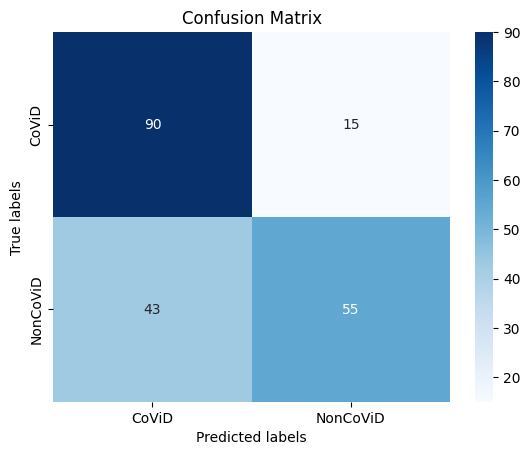

In [ ]:
import seaborn as sns

conf_matrix = conf_matrix
ax= plt.subplot()
sns.heatmap(conf_matrix, annot=True, ax = ax, cmap = 'Blues'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['CoViD', 'NonCoViD']); ax.yaxis.set_ticklabels(['CoViD', 'NonCoViD']);